# ARIMA 3 - SARIMA, ARIMAX, SARIMAX
- Revisão
- Treinar identificação de AR e MA
- Modelos incompletos
- Modelos Sazonais
- Utlizando variáveis exógenas
- SARIMAX

In [37]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
plt.rcParams["figure.figsize"] = [12, 5]

def all_ac(Y):
    fig, ax = plt.subplots(1, 2, figsize=(16,5))
    plot_acf(Y, zero=False, ax=ax[0])
    ax[0].set_title('ACF')
    plot_pacf(Y, zero=False, ax=ax[1])
    ax[1].set_title('PACF')
    plt.show()

def plot_forecast(serie_original, previsao):
    plt.plot(serie_original, label='Serie Histórica', linestyle='-')  
    plt.plot(previsao, label='Previsão', linestyle='--')  
    plt.xlabel('Data')
    plt.ylabel('Valores')
    plt.title('Serie histórica com previsão')
    plt.legend()
    plt.show()
    
def teste_estacionariedade(s):
    kps = kpss(s)
    adf = adfuller(s)
    kpss_pv, adf_pv = kps[1], adf[1]
    kpssh, adfh = 'Estacionário', 'Não Estacionário'
    if adf_pv < 0.05:
        adfh = 'Estacionário'
    if kpss_pv < 0.05:
        kpssh = 'Não Estacionário'
    return (kpssh, adfh)

## Último modelo que fizemos

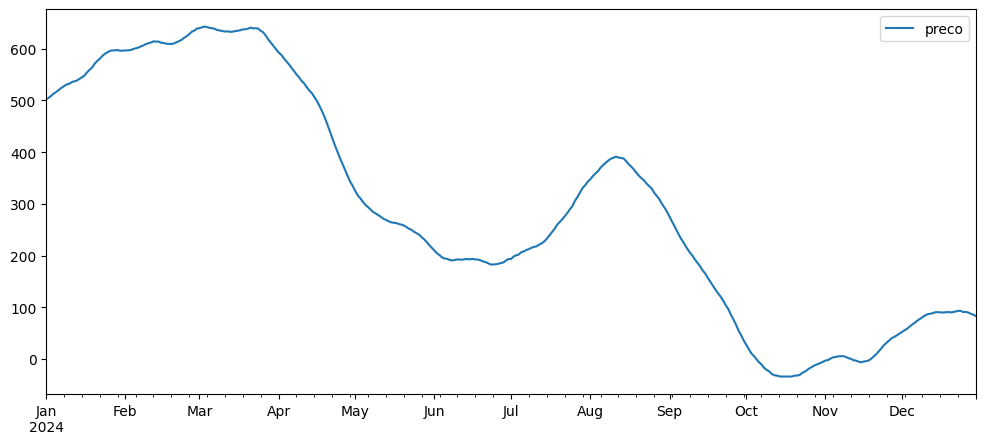

In [38]:
Y = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/ARIMA_Exemplo.csv')
Y.index = pd.date_range(start='2024-01-01', periods = 365)
Y.plot()
plt.show()

In [39]:
teste_estacionariedade(Y)

/var/folders/f1/tdh3lyp114g78tg5wv2t7g3m0000gn/T/ipykernel_5721/2813291160.py:27: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kps = kpss(s)


('Não Estacionário', 'Não Estacionário')

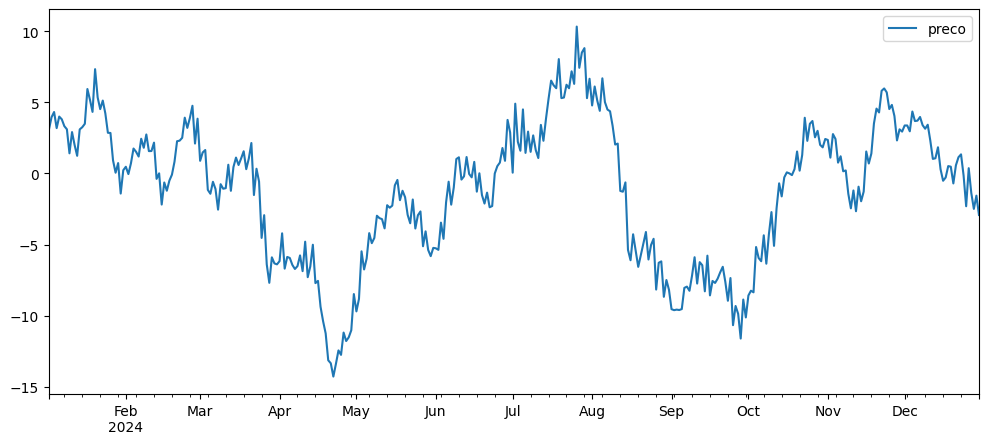

/var/folders/f1/tdh3lyp114g78tg5wv2t7g3m0000gn/T/ipykernel_5721/2813291160.py:27: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s)


('Estacionário', 'Estacionário')

In [40]:
primeira_ordem = Y.diff().dropna()
primeira_ordem.plot()
plt.show()
teste_estacionariedade(primeira_ordem)

In [41]:
def diagnostico(model):
    print(model.summary())
    model.plot_diagnostics()
    plt.show()
    residuo = model.resid
    residuo = residuo[1:] 
    all_ac(residuo)
    plt.show()

                               SARIMAX Results                                
Dep. Variable:                  preco   No. Observations:                  365
Model:                 ARIMA(2, 1, 3)   Log Likelihood                -514.589
Date:                Tue, 04 Mar 2025   AIC                           1041.178
Time:                        14:39:20   BIC                           1064.561
Sample:                    01-01-2024   HQIC                          1050.472
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5211      0.053      9.863      0.000       0.418       0.625
ar.L2          0.4295      0.054      7.886      0.000       0.323       0.536
ma.L1         -0.0321      0.025     -1.286      0.1

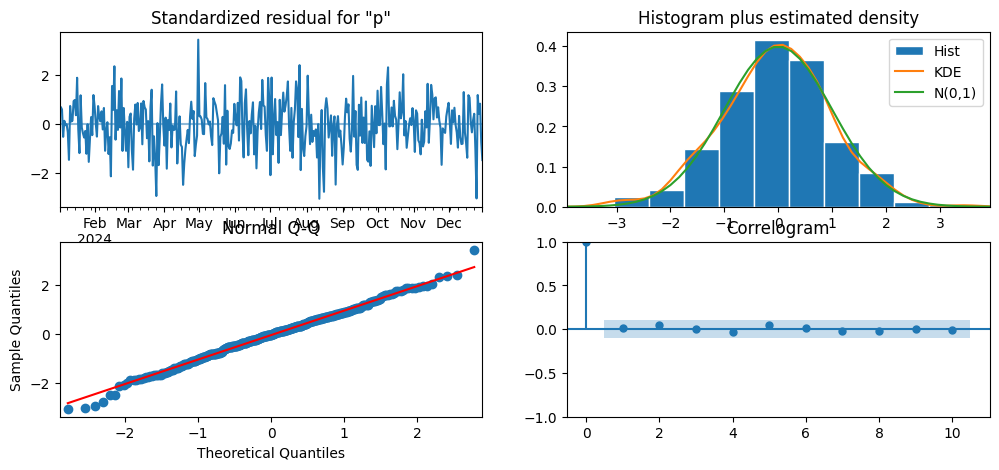

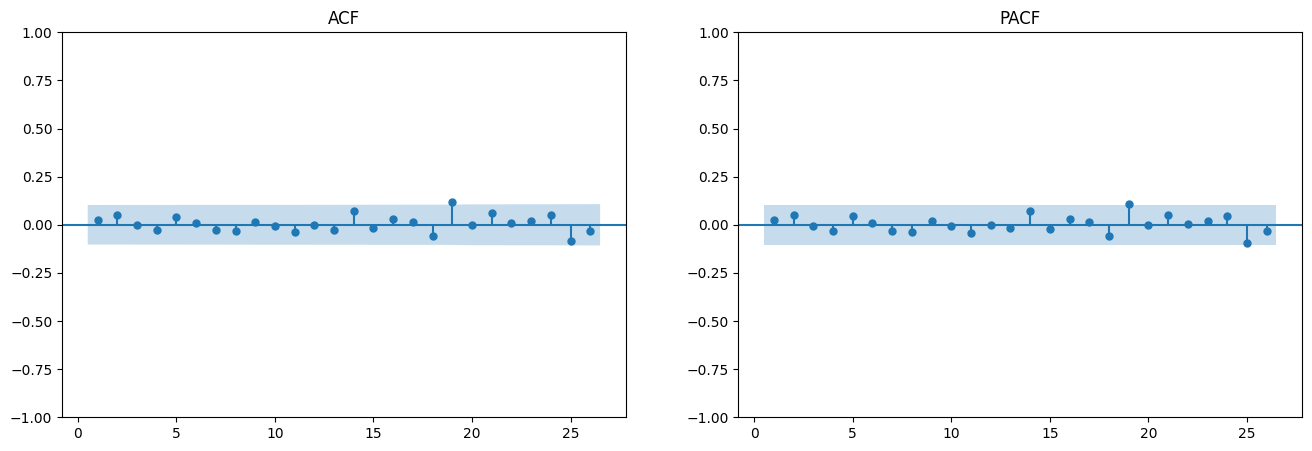

In [42]:
model = ARIMA(Y, order=(2, 1, 3)).fit()
diagnostico(model)

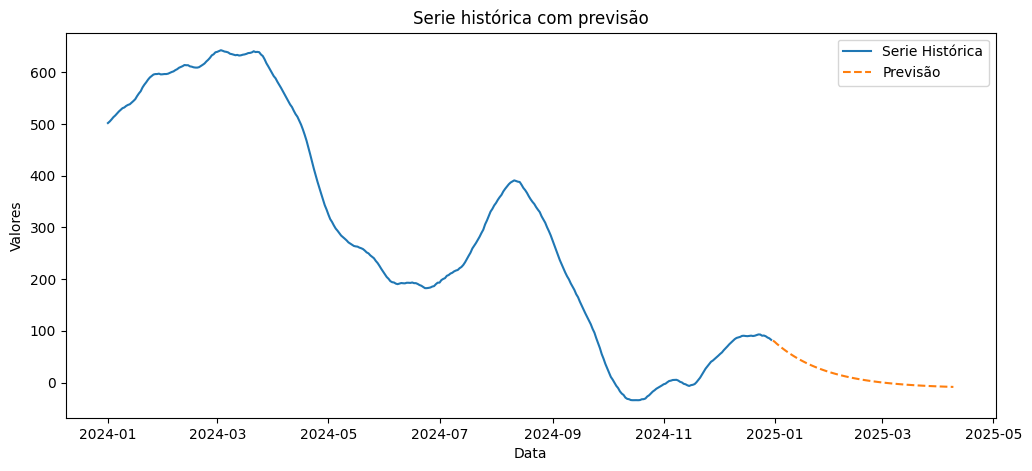

In [43]:
previsao = model.forecast(100)
plot_forecast(Y,previsao)

## Modelos incompletos

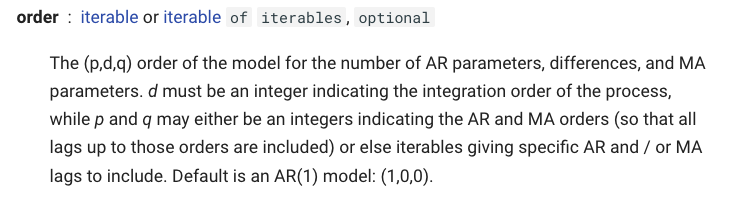

                               SARIMAX Results                                
Dep. Variable:                  preco   No. Observations:                  365
Model:               ARIMA(2, 1, [3])   Log Likelihood                -515.275
Date:                Tue, 04 Mar 2025   AIC                           1038.549
Time:                        14:52:26   BIC                           1054.138
Sample:                    01-01-2024   HQIC                          1044.745
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4931      0.047     10.540      0.000       0.401       0.585
ar.L2          0.4567      0.048      9.528      0.000       0.363       0.551
ma.L3          0.9217      0.023     39.346      0.0

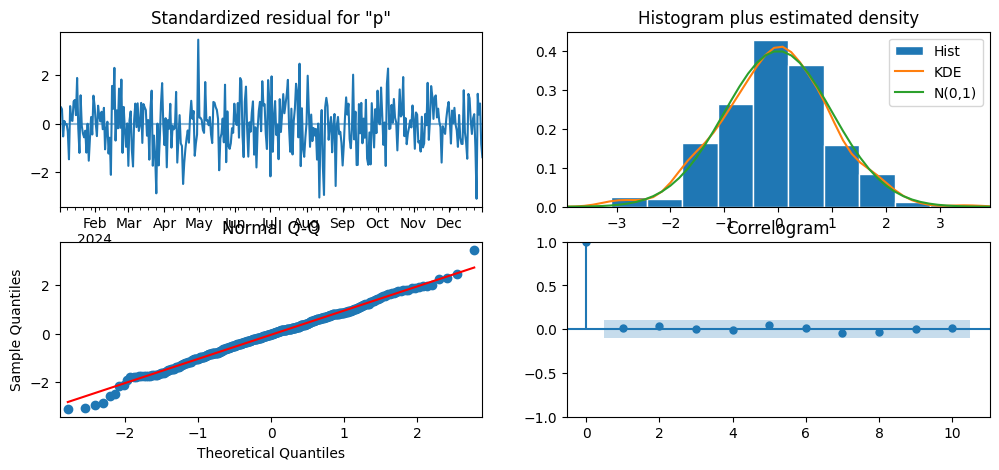

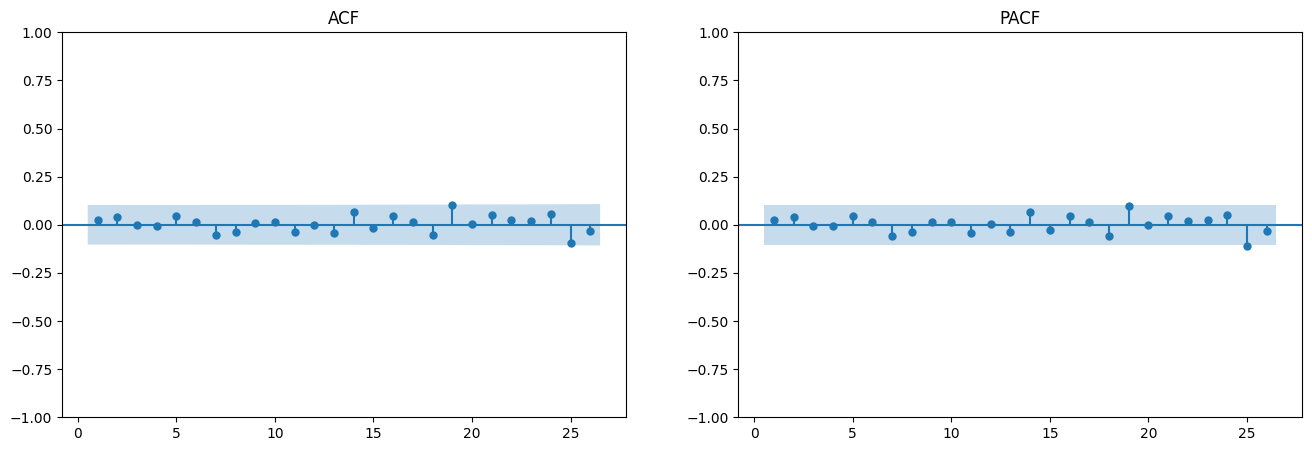

In [55]:
model = ARIMA(Y, order=(2, 1, (0,0,1))).fit()
diagnostico(model)

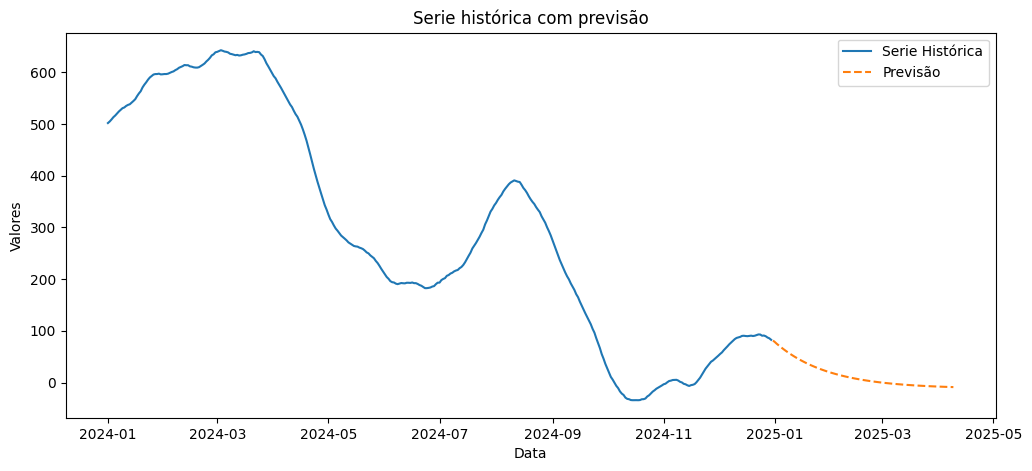

In [52]:
previsao = model.forecast(100)
plot_forecast(Y,previsao)

ARIMA(2,1,(0,0,1))
$$ \large (1 - B) Y_t = \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \theta_3 \epsilon_{t-3} + \epsilon_t $$

$$ \large (1 - B) Y_t = 0.493 Y_{t-1} + 0.457 Y_{t-2} + 0.922 \epsilon_{t-3} + \epsilon_t $$

In [53]:
model.params

ar.L1     0.493122
ar.L2     0.456669
ma.L3     0.921652
sigma2    0.969362
dtype: float64

## Treinando identificação de séries

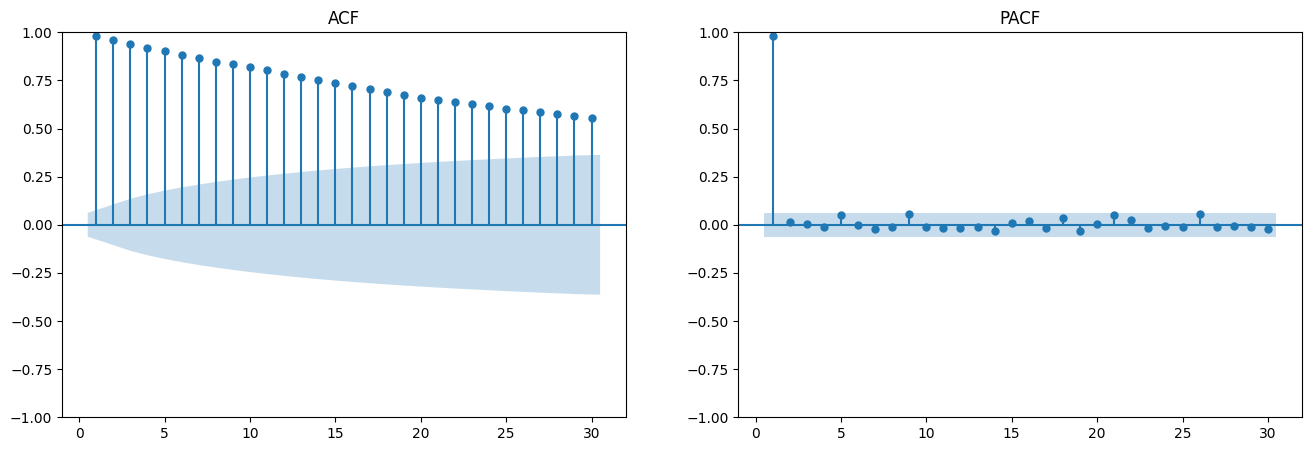

In [29]:
import geracao_de_series as gc
np.random.seed(42)
Y = pd.Series(gc.generate_ar_series([0.98], n_samples=1000))
all_ac(Y)

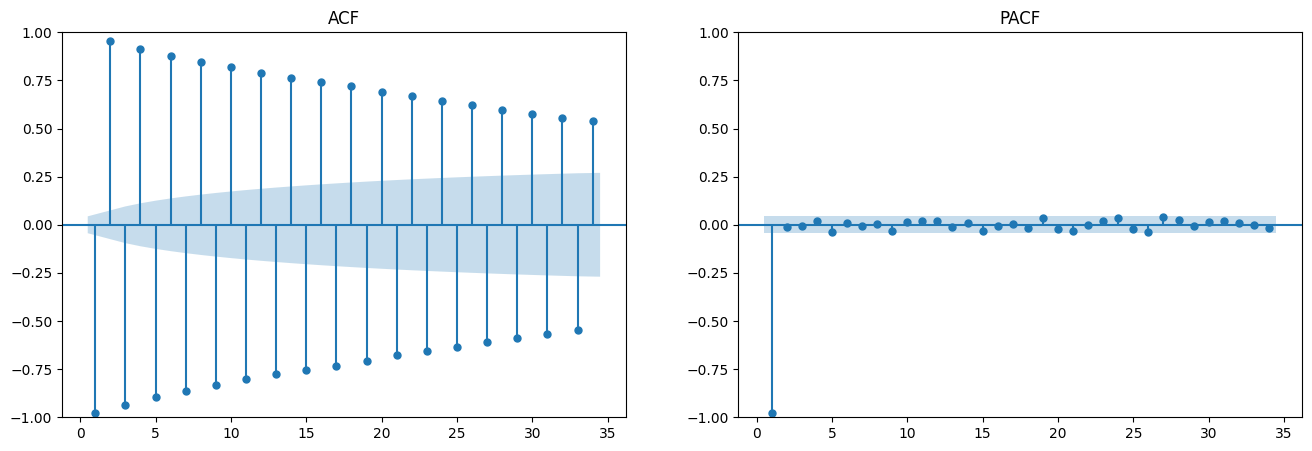

In [30]:
np.random.seed(42)
Y = pd.Series(gc.generate_ar_series([-0.98]))
all_ac(Y)

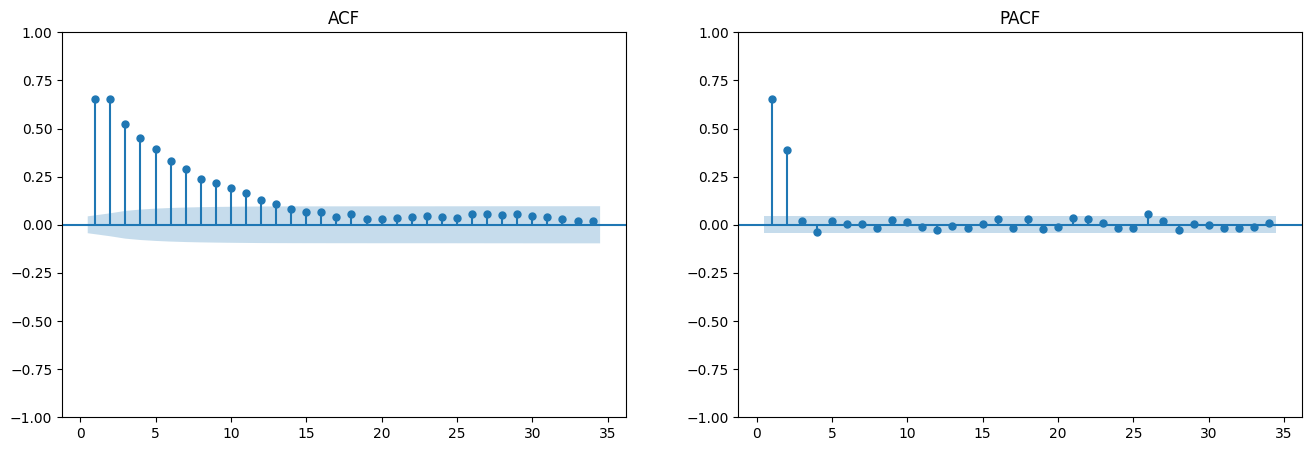

In [31]:
np.random.seed(42)
Y = pd.Series(gc.generate_ar_series([0.4, 0.4]))
all_ac(Y)

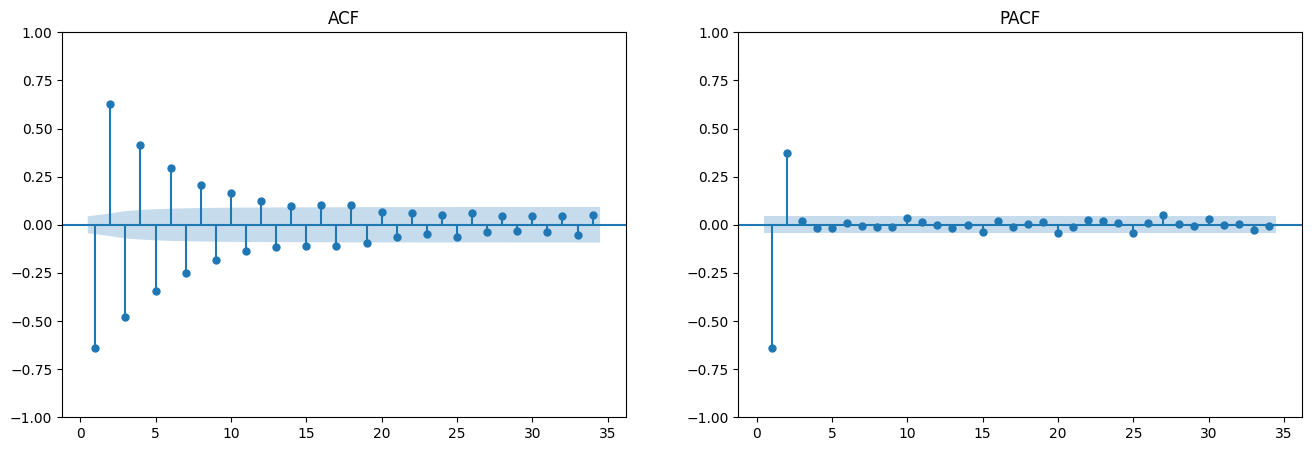

In [32]:
np.random.seed(42)
Y = pd.Series(gc.generate_ar_series([-0.4, 0.4]))
all_ac(Y)

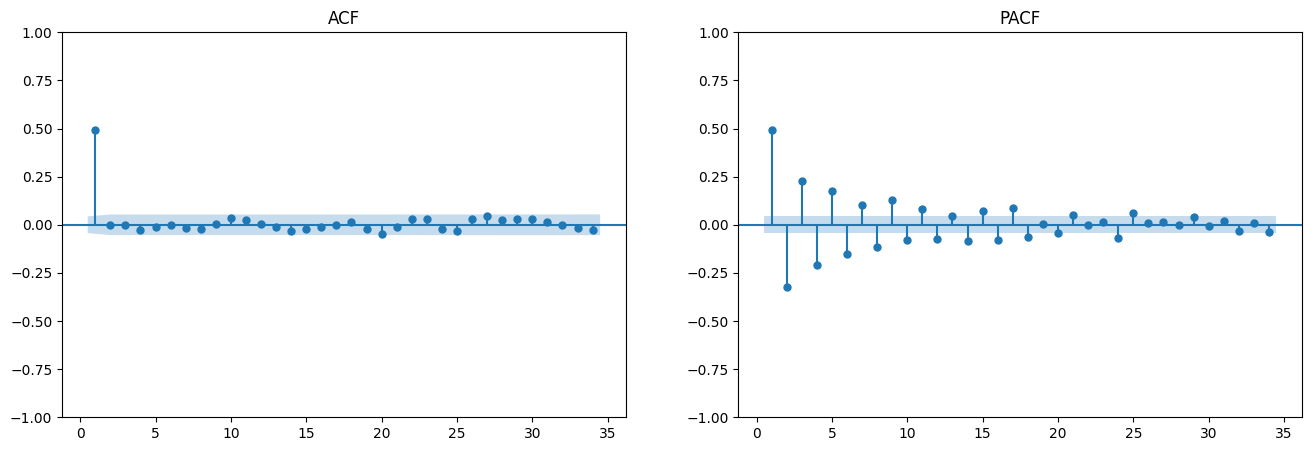

In [33]:
np.random.seed(42)
Y = pd.Series(gc.generate_ma_series([0.98]))
all_ac(Y)

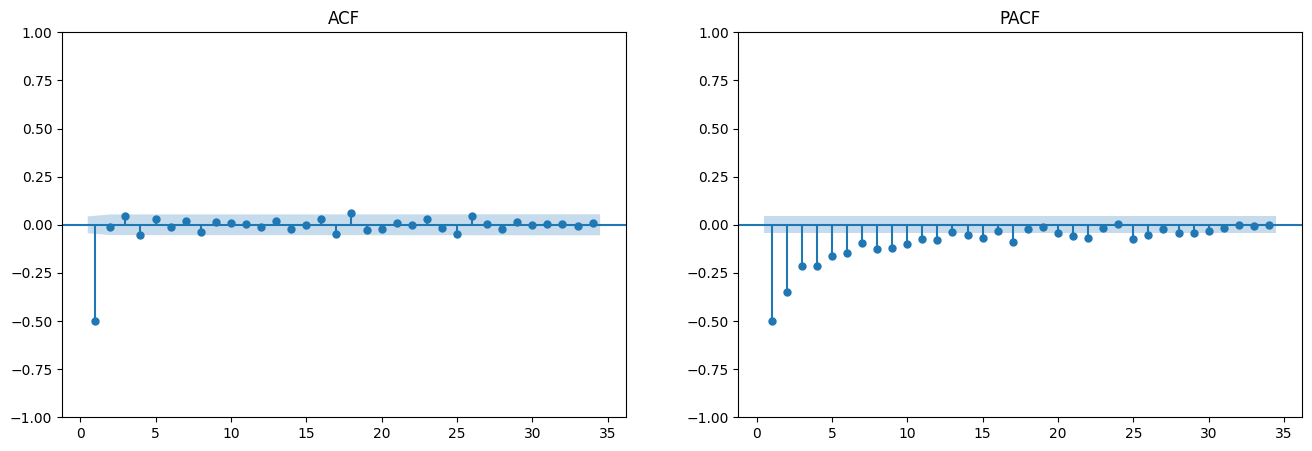

In [34]:
np.random.seed(42)
Y = pd.Series(gc.generate_ma_series([-0.98]))
all_ac(Y)

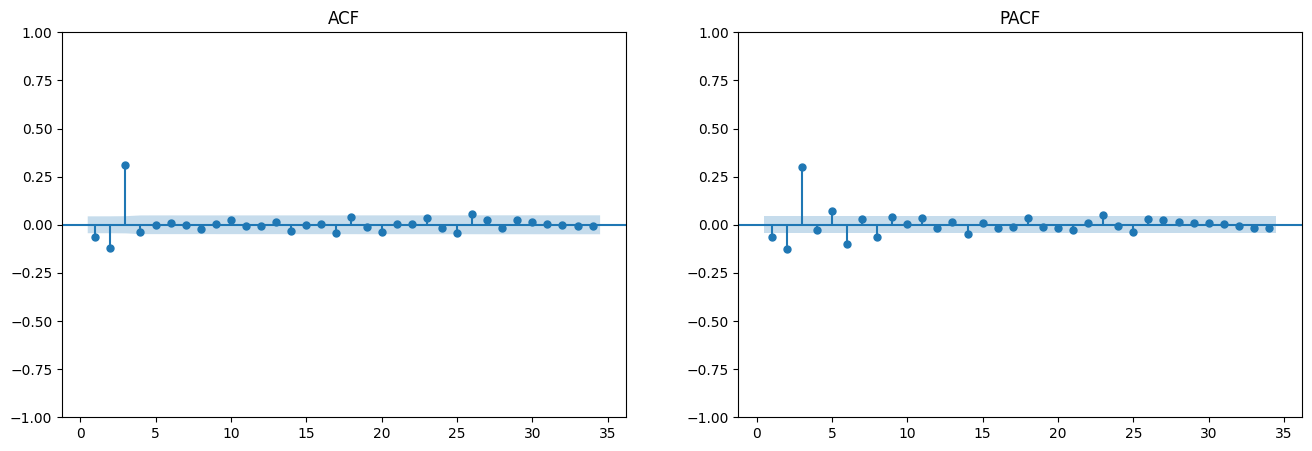

In [35]:
np.random.seed(42)
Y = pd.Series(gc.generate_ma_series([-0.4, -0,3]))
all_ac(Y)

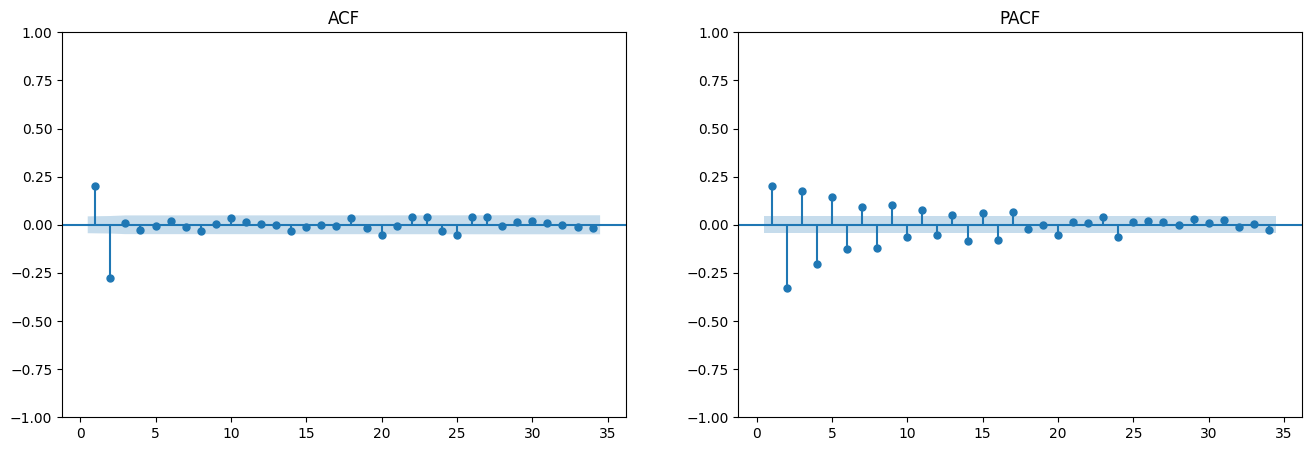

In [36]:
np.random.seed(42)
Y = pd.Series(gc.generate_ma_series([0.5,-0.4]))
all_ac(Y)

## SARIMA

$$
\large (1 - B)^d (1 - B^s)^D Y_t = c + \phi_1 Y_{t-1} + \dots + \phi_p Y_{t-p} + \Phi_1 Y_{t-s} + \dots + \Phi_P Y_{t-Ps} + \epsilon_t + \theta_1 \epsilon_{t-1} + \dots + \theta_q \epsilon_{t-q} + \Theta_1 \epsilon_{t-s} + \dots + \Theta_Q \epsilon_{t-Qs}
$$

### SARIMA (1,0,1)(1,0,1)_12
$$
\large (1 - \phi_1 B)(1 - \Phi_1 B^{12}) Y_t = c + (1 + \theta_1 B)(1 + \Theta_1 B^{12}) \epsilon_t
$$

$$
\large Y_t = c + \phi_1 Y_{t-1} + \Phi_1 Y_{t-12} - \phi_1 \Phi_1 Y_{t-13} + \epsilon_t + \theta_1 \epsilon_{t-1} + \Theta_1 \epsilon_{t-12} + \theta_1 \Theta_1 \epsilon_{t-13}
$$


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(data, 
                order=(1, 0, 1), 
                seasonal_order=(1, 0, 1, 12)).fit()

In [56]:
milk = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/milk_production.csv')

<Axes: >

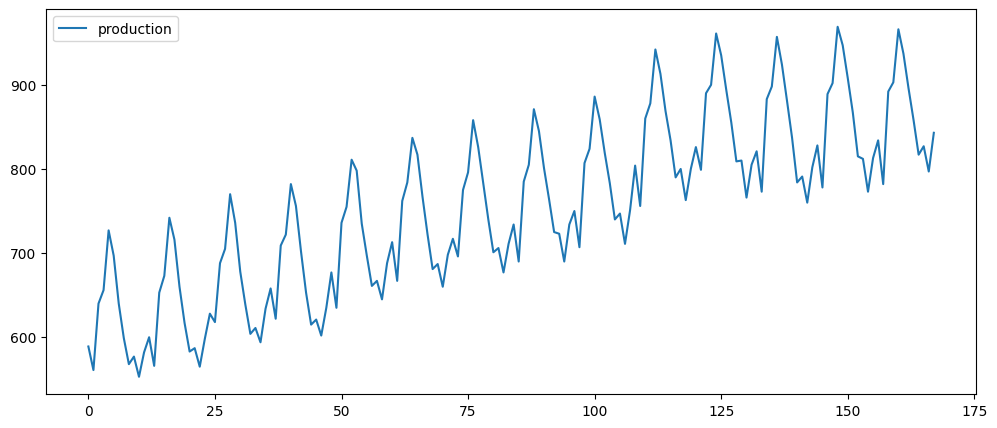

In [58]:
milk.plot()